In [52]:
# %matplotlib ipympl

In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import miniball
import networkx as nx

## Importing `.gro` file

In [81]:
#setting column specifications
colspecs = [
    (0, 5),
    (5, 8),
    (8, 15),
    (15, 20),
    (20, 28),
    (28, 36),
    (36, 44),
    (44, 52),
    (52, 60),
    (60, 68),
]

#setting names of columns
names = ["res_id", "res_name", "atom_name", "atom_id", "x", "y", "z", "Vx", "Vy", "Vz"]

#reading data
data = pd.read_fwf(
    "../../../data/npt-HK4.gro",
    colspecs=colspecs,
    names=names,
    skiprows=2,
    skipfooter=1,
)

# Problem: after atom id 99999, it reverts back to 0. The following solves this:
for i in data.index:
    if i >= 99999:
        data.at[i,'atom_id'] += 100000

#reading Title, number of atoms and box_dimensions
with open("../../../data/npt-HK4.gro", "rb") as f:
    title = f.readline().decode().strip() #First line of .gro file
    num_atoms = f.readline().decode().strip() #Second line of .gro file

    #Last line of file
    f.seek(-2, 2)
    while f.read(1) != b"\n":
        f.seek(-2, 1)
    box_dimensions = f.readline().decode().strip()


print(data.head())
print(f"Title: {title}")
print(f"Number of atoms: {num_atoms}")
print(f"Box dimensions: {box_dimensions}")

   res_id res_name atom_name  atom_id      x      y      z      Vx      Vy  \
0       1      HK4       H28        1  1.602  0.962  0.912 -0.0935  0.8795   
1       1      HK4       C48        2  1.565  0.879  0.852 -0.2814 -0.6983   
2       1      HK4       C47        3  1.655  0.809  0.773  0.4154  0.1398   
3       1      HK4       H27        4  1.754  0.855  0.756  0.1277  0.7999   
4       1      HK4       C46        5  1.603  0.717  0.683 -0.0655  0.7587   

       Vz  
0 -2.1573  
1  0.0954  
2  0.1445  
3  0.2091  
4 -0.2231  
Title: mol only system in water
Number of atoms: 126084
Box dimensions: 11.24798  11.24798  11.24798


In [84]:
data.loc[10000]

res_id          120
res_name        HK4
atom_name       C46
atom_id       10001
x              5.05
y             7.968
z             2.341
Vx           0.4869
Vy           0.3997
Vz          -0.0404
Name: 10000, dtype: object

## Filter out 10 molecules

In [82]:
filtered_data = data[(data["res_id"] >= 1) & (data["res_id"] <= 10)][["res_id", "res_name", "atom_name", "atom_id", "x", "y", "z"]]

In [56]:
filtered_data.set_index(['res_id', 'atom_name'], inplace=True) 

In [57]:
print(filtered_data.loc[3])  # Select all atoms in residue 3
print("\n \n")
print(filtered_data.loc[(1, "H28")]) # Select specific atom in residue 3

          res_name  atom_id       x       y      z
atom_name                                         
H28            HK4      169  11.068  10.369  0.589
C48            HK4      170  11.109  10.443  0.659
C47            HK4      171  11.241  10.441  0.703
H27            HK4      172   0.060  10.361  0.667
C46            HK4      173   0.041  10.554  0.766
...            ...      ...     ...     ...    ...
H23            HK4      248   0.180  10.422  1.296
C44            HK4      249   0.196  10.590  1.436
H24            HK4      250   0.182  10.527  1.525
C45            HK4      251   0.196  10.728  1.450
H25            HK4      252   0.162  10.773  1.545

[84 rows x 5 columns]

 

res_name      HK4
atom_id         1
x           1.602
y           0.962
z           0.912
Name: (1, H28), dtype: object


## Finding midpoints of Oxygen atoms

In [58]:
# Extract box length from box_dimensions string 
box_length = float(box_dimensions.split()[0])

In [59]:
def compute_midpoints_df(filtered_data, box_length):
    """
    Given a multi-indexed DataFrame (filtered_data) and box_length,
    returns a DataFrame with columns ['res_id', 'mid_x', 'mid_y', 'mid_z']
    containing the midpoints between O1 and O2 atoms for each residue.
    """
    def minimum_image(dx, box_length):
        reciprocal_half_box = 1.0 / (0.5 * box_length)
        k = int(dx * reciprocal_half_box)
        return dx - k * box_length

    def midpoint_pbc(p1, p2, box_length):
        dx = p2 - p1
        dx_mic = minimum_image(dx, box_length)
        midpoint = (p1 + 0.5 * dx_mic) % box_length
        return midpoint

    midpoints = []
    for res_id in filtered_data.index.get_level_values(0).unique():
        try:
            o1 = filtered_data.loc[(res_id, "O1")]
            o2 = filtered_data.loc[(res_id, "O2")]
            mx = midpoint_pbc(o1['x'], o2['x'], box_length)
            my = midpoint_pbc(o1['y'], o2['y'], box_length)
            mz = midpoint_pbc(o1['z'], o2['z'], box_length)
            midpoints.append({'res_id': res_id, 'mid_x': mx, 'mid_y': my, 'mid_z': mz})
        except KeyError:
            # Skip residues without both O1 and O2
            continue

    return pd.DataFrame(midpoints)

In [60]:
midpoints_df = compute_midpoints_df(filtered_data, box_length)
print(midpoints_df)

   res_id    mid_x     mid_y     mid_z
0       1  1.55850   0.40900  11.16949
1       2  0.44150   0.65700  10.78750
2       3  0.76450  10.72000   0.89800
3       4  0.15751   0.97750   0.13500
4       5  5.54400   0.11051   5.77600
5       6  9.27550   6.66500   0.76350
6       7  6.80200  10.02350   7.06650
7       8  2.56550   6.91200   6.94750
8       9  7.90450   9.26750   8.47950
9      10  1.73000   8.84150   2.43050


In [61]:
# Add midpoint coordinates as new columns to filtered_data at the residue level
for idx, row in midpoints_df.iterrows():
    filtered_data.loc[(row['res_id'], slice(None)), 'midO_x'] = row['mid_x']
    filtered_data.loc[(row['res_id'], slice(None)), 'midO_y'] = row['mid_y']
    filtered_data.loc[(row['res_id'], slice(None)), 'midO_z'] = row['mid_z']

filtered_data

res_name  atom_id      x      y      z  midO_x  midO_y  \
res_id atom_name                                                          
1      H28            HK4        1  1.602  0.962  0.912  1.5585  0.4090   
       C48            HK4        2  1.565  0.879  0.852  1.5585  0.4090   
       C47            HK4        3  1.655  0.809  0.773  1.5585  0.4090   
       H27            HK4        4  1.754  0.855  0.756  1.5585  0.4090   
       C46            HK4        5  1.603  0.717  0.683  1.5585  0.4090   
...                   ...      ...    ...    ...    ...     ...     ...   
10     H23            HK4      836  1.155  8.881  2.907  1.7300  8.8415   
       C44            HK4      837  1.312  8.961  2.794  1.7300  8.8415   
       H24            HK4      838  1.237  8.973  2.714  1.7300  8.8415   
       C45            HK4      839  1.441  9.012  2.786  1.7300  8.8415   
       H25            HK4      840  1.453  9.078  2.699  1.7300  8.8415   

                    midO_z  
res_id atom_name            
1      H28        11.16949  
       C48        11.16949  
       C47        11.16949  
       H27        11.16949  
       C46        11.16949  
...                    ...  
10     H23         2.43050  
       C44         2.43050  
       H24         2.43050  
       C45         2.43050  
       H25         2.43050  

[840 rows x 8 columns]

## Modeling molecules as spheres

In [ ]:
def mic_vector(dx, box_length):
    """Minimum image displacement for array dx."""
    return dx - np.rint(dx / box_length) * box_length

def mic_distance(p1, p2, box_length):
    """Minimum image Euclidean distance."""
    dx = mic_vector(p2 - p1, box_length)
    return np.linalg.norm(dx)

def mec_pbc_miniball(positions, box_length, references=None):
    """
    Finds approximate minimum enclosing sphere under PBC using the miniball library.
    positions: (n,3) array
    box_length: float
    references: list of indices to try as reference points (default: all points)
    Returns: center (3,), radius (float)
    """
    n = len(positions)
    if references is None:
        references = range(n)
    
    best_center = None
    best_radius = np.inf
    
    for i in references:
        ref = positions[i]
        
        # Unwrap positions relative to reference
        diffs = positions - ref
        diffs = mic_vector(diffs, box_length)
        unwrapped = ref + diffs
        
        # Compute Euclidean MEB via miniball
        center_unwrapped, radius_unwrapped_sq = miniball.get_bounding_ball(unwrapped)
        radius_unwrapped = np.sqrt(radius_unwrapped_sq)
        
        # Map center into primary box
        center_primary = np.mod(center_unwrapped, box_length)
        
        # Check radius under true PBC
        dists = np.array([mic_distance(center_primary, p, box_length) for p in positions])
        radius_check = np.max(dists)
        
        if radius_check < best_radius:
            best_radius = radius_check
            best_center = center_primary
    
    return best_center, best_radius

#### Examples

In [63]:
# Get all atoms for residue 8
res8_atoms = filtered_data.loc[8]

# Extract their coordinates as a NumPy array (shape: n_atoms x 3)
positions = res8_atoms[['x', 'y', 'z']].values.astype(float)

# Compute center and radius using mec_pbc_miniball
center, radius = mec_pbc_miniball(positions, box_length)

print("Center:", center)
print("Radius:", radius)

Center: [3.07232275 6.92917937 6.94084915]
Radius: 0.8181120003445479


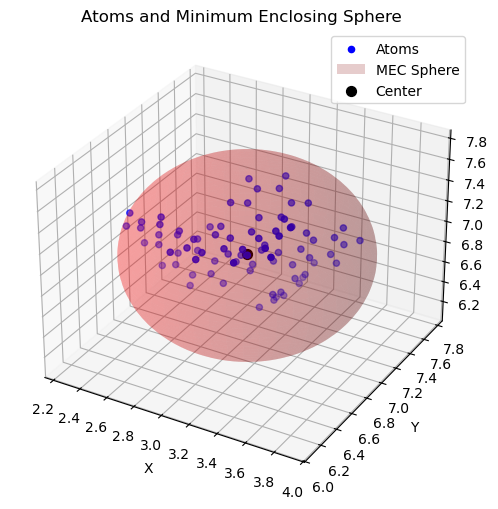

In [64]:
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')

# Plot all points in positions
ax.scatter(positions[:, 0], positions[:, 1], positions[:, 2], color='b', label='Atoms')

# Plot the sphere surface
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)
x_sphere = center[0] + radius * np.outer(np.cos(u), np.sin(v))
y_sphere = center[1] + radius * np.outer(np.sin(u), np.sin(v))
z_sphere = center[2] + radius * np.outer(np.ones_like(u), np.cos(v))

ax.plot_surface(x_sphere, y_sphere, z_sphere, color='r', alpha=0.2, label='MEC Sphere')

# Mark the center
ax.scatter(center[0], center[1], center[2], color='k', s=50, label='Center')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Atoms and Minimum Enclosing Sphere')
ax.legend()
plt.show()

### Apply to n molecules

In [65]:
def compute_centers_radii(dataframe, box_length):
    """
    Given a multi-indexed DataFrame (dataframe) and box_length,
    returns a DataFrame with columns ['res_id', 'center_x', 'center_y', 'center_z', 'radius']
    containing the minimum enclosing sphere center and radius for each residue.
    """
    results = []
    for res_id in dataframe.index.get_level_values(0).unique():
        atoms = dataframe.loc[res_id]
        positions = atoms[['x', 'y', 'z']].values.astype(float)
        center, radius = mec_pbc_miniball(positions, box_length)
        results.append({'res_id': res_id, 'center': center, 'radius': radius})

    centers_radii_df = pd.DataFrame([{
        'res_id': r['res_id'],
        'center_x': r['center'][0],
        'center_y': r['center'][1],
        'center_z': r['center'][2],
        'radius': r['radius']
    } for r in results])

    return centers_radii_df

In [66]:
centers_radii_df = compute_centers_radii(filtered_data, box_length)
print(centers_radii_df)

   res_id  center_x   center_y   center_z    radius
0       1  1.152500   0.358510   0.308010  0.964912
1       2  0.365959   0.459334  11.170685  0.764553
2       3  0.290964  10.827618   1.044711  0.799869
3       4  0.638283   1.062344   0.032606  0.807502
4       5  5.635702  10.943064   5.478127  0.863362
5       6  9.043500   6.893000   0.972500  0.985522
6       7  6.852177   9.731174   6.720748  0.972062
7       8  3.072323   6.929179   6.940849  0.818112
8       9  7.725686   9.419816   8.009204  0.845095
9      10  1.419549   9.255030   2.515032  0.841134


### Visualizing 10 molecules

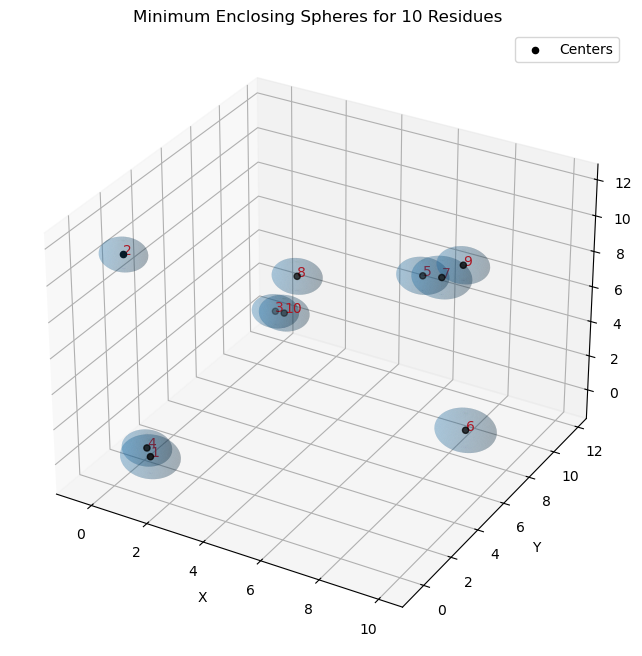

In [67]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot each sphere for the 10 residues
u = np.linspace(0, 2 * np.pi, 50)
v = np.linspace(0, np.pi, 50)
for _, row in centers_radii_df.iterrows():
    cx, cy, cz, r = row['center_x'], row['center_y'], row['center_z'], row['radius']
    x_sphere = cx + r * np.outer(np.cos(u), np.sin(v))
    y_sphere = cy + r * np.outer(np.sin(u), np.sin(v))
    z_sphere = cz + r * np.outer(np.ones_like(u), np.cos(v))
    ax.plot_surface(x_sphere, y_sphere, z_sphere, alpha=0.2, color='C0')

# Mark the centers
ax.scatter(centers_radii_df['center_x'], centers_radii_df['center_y'], centers_radii_df['center_z'], color='k', s=20, label='Centers')

# Annotate each center with its residue number
for _, row in centers_radii_df.iterrows():
    ax.text(row['center_x'], row['center_y'], row['center_z'], str(int(row['res_id'])), color='red', fontsize=10)


ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Minimum Enclosing Spheres for 10 Residues')
ax.legend()
plt.show()

## Blocking algorithm

In [68]:
from numpy.linalg import norm

def is_blocked(center1, center2, centers_radii_df, tol=1e-8):
    """
    Test if any third sphere blocks the direct path between two spheres. Returns True if blocked, False otherwise.

    centers_radii_df: DataFrame with columns ['center_x', 'center_y', 'center_z', 'radius']
    tol: float, numerical tolerance
    """

    # Vector from center1 to center2
    p1 = np.array(center1)
    p2 = np.array(center2)
    d = p2 - p1
    d_norm = norm(d)
    if d_norm < tol:
        return False  # same center

    # For each third sphere
    for idx, row in centers_radii_df.iterrows():
        c = np.array([row['center_x'], row['center_y'], row['center_z']])
        r = row['radius']

        # Skip if c is center1 or center2
        if np.allclose(c, p1, atol=tol) or np.allclose(c, p2, atol=tol):
            continue

        # Project c onto the line segment p1-p2
        t = np.dot(c - p1, d) / (d_norm ** 2)
        t = np.clip(t, 0, 1)
        closest = p1 + t * d
        dist = norm(c - closest)

        if dist < r - tol:
            return True  # blocked

    return False  # not blocked

In [69]:
def get_not_blocked_pairs(centers_radii_df):
    """
    Returns a list of tuples (res_id1, res_id2) for residue pairs that are NOT blocked.
    """
    not_blocked_pairs = []

    for i in range(len(centers_radii_df)):
        for j in range(i + 1, len(centers_radii_df)):
            c1 = centers_radii_df.iloc[i][['center_x', 'center_y', 'center_z']]
            c2 = centers_radii_df.iloc[j][['center_x', 'center_y', 'center_z']]
            blocked = is_blocked(c1, c2, centers_radii_df)
            if not blocked:
                res_id1 = int(centers_radii_df.iloc[i]['res_id'])
                res_id2 = int(centers_radii_df.iloc[j]['res_id'])
                not_blocked_pairs.append((res_id1, res_id2))
                
    return not_blocked_pairs

In [ ]:
get_not_blocked_pairs(centers_radii_df)

[(1, 2),
 (1, 4),
 (1, 5),
 (1, 6),
 (1, 7),
 (1, 8),
 (1, 9),
 (2, 3),
 (2, 5),
 (2, 6),
 (2, 7),
 (2, 8),
 (2, 9),
 (2, 10),
 (3, 5),
 (3, 6),
 (3, 7),
 (3, 10),
 (5, 6),
 (5, 7),
 (5, 8),
 (5, 10),
 (6, 7),
 (6, 8),
 (6, 9),
 (6, 10),
 (7, 8),
 (7, 9),
 (7, 10),
 (8, 9),
 (8, 10)]

## Neighbouring molecules graph

In [ ]:
G = nx.Graph()

not_blocked_pairs = get_not_blocked_pairs(centers_radii_df)

G.add_edges_from(not_blocked_pairs)

print(G)

Graph with 10 nodes and 31 edges


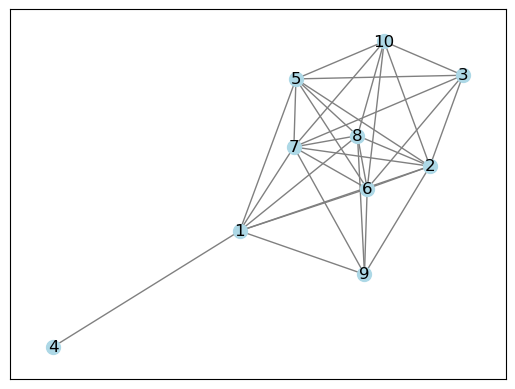

In [ ]:
nx.draw_networkx(G, node_color='lightblue', edge_color='gray', node_size=100)
plt.show()

## 100 molecules

In [74]:
data_100 = data[(data["res_id"] >= 1) & (data["res_id"] <= 100)][["res_id", "res_name", "atom_name", "atom_id", "x", "y", "z"]]

data_100.set_index(['res_id', 'atom_name'], inplace=True) 

In [75]:
box_length = float(box_dimensions.split()[0])

centers_radii_df = compute_centers_radii(data_100, box_length)

In [77]:
G = nx.Graph()

edges = get_not_blocked_pairs(centers_radii_df)

G.add_edges_from(edges)

print(G)

Graph with 100 nodes and 1844 edges
